<a href="https://colab.research.google.com/github/taariq20/816042980COMP3610Assignment3/blob/main/assignment3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP3610 Assignment 3: NYC Taxi Analytics & RAG Assistant

# Part 1: Spark Data Engineering

## Task 1.1: Spark Environment Setup & Data Loading

In this section, a SparkSession is initialized with Adaptive Query Execution (AQE) enabled for improved performance. The NYC Yellow Taxi trip data and the taxi zone lookup table are then downloaded, and the primary dataset is loaded into a Spark DataFrame.

In [1]:
# Import and install necessary libraries
# Spark for distributed computing
# Matplotlib/Seaborn for data visualization.
# LangChain for RAG orchestration

!pip install pypdf langchain langchain-community chromadb openai
import os
import time
import warnings
warnings.filterwarnings('ignore')

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

SEED = 42
print("All imports successful!")

All imports successful!


### 1.1a  Create a SparkSession
Adaptive Query Execution (AQE) is enabled, allowing Spark to re-optimise the physical plan at runtime based on actual partition statistics, which is particularly useful for handling data skew and dynamically adjusting join strategies after shuffles.

In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("COMP3610-Assignment3-NYC-Taxi")
    .config("spark.driver.memory", "4g")
    .config("spark.executor.memory", "4g")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print(f"Spark version      : {spark.version}")
print(f"App name           : {spark.sparkContext.appName}")
print(f"Master             : {spark.sparkContext.master}")
print(f"Default parallelism: {spark.sparkContext.defaultParallelism}")
print(f"Spark UI           : http://localhost:4040")

Spark version      : 4.0.2
App name           : COMP3610-Assignment3-NYC-Taxi
Master             : local[*]
Default parallelism: 2
Spark UI           : http://localhost:4040


### 1.1b  Download data
The NYC Yellow Taxi Trip Records (January 2024) are downloaded, aswell as the taxi look up zones.

In [3]:
import os, requests

TRIP_URL  = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet"
ZONE_URL  = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
TRIP_FILE = "yellow_tripdata_2024-01.parquet"
ZONE_FILE = "taxi_zone_lookup.csv"

def download_if_missing(url, path):
    if not os.path.exists(path):
        print(f"Downloading {path} ...")
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        with open(path, "wb") as f:
            f.write(r.content)
        print(f"  → saved ({len(r.content)/1e6:.1f} MB)")
    else:
        print(f"{path} already present ({os.path.getsize(path)/1e6:.1f} MB)")

download_if_missing(TRIP_URL, TRIP_FILE)
download_if_missing(ZONE_URL, ZONE_FILE)

yellow_tripdata_2024-01.parquet already present (50.0 MB)
taxi_zone_lookup.csv already present (0.0 MB)


### 1.1c  Load into Spark DataFrame
All columns are loaded here so that the full schema is visible, with downstream tasks selecting or dropping columns as needed.

In [4]:
import time

t_spark_start = time.time()
sdf = spark.read.parquet(TRIP_FILE)
sdf.cache()
row_count = sdf.count()
spark_load_time = time.time() - t_spark_start

print("\n── Schema ──────────────────────────────────────────────────────")
sdf.printSchema()

print(f"\n── Summary ─────────────────────────────────────────────────────")
print(f"  Total rows      : {row_count:,}")
print(f"  Partitions      : {sdf.rdd.getNumPartitions()}")
print(f"  Spark load time : {spark_load_time:.2f}s")

sdf.select("trip_distance", "fare_amount", "tip_amount", "total_amount") \
   .summary("count", "mean", "stddev", "min", "max") \
   .show()


── Schema ──────────────────────────────────────────────────────
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)


── Summary ───────────────────────────────────────────────

### 1.1d Compare load times
The load time comparison between Spark and Pandas is performed, where Pandas reads the entire file eagerly into memory in a single process, while Spark distributes the read across partitions and, after caching, stores the data in memory to avoid repeated disk I/O in subsequent operations.

In [5]:
import pandas as pd

t_pd_start = time.time()
pdf = pd.read_parquet(TRIP_FILE)
pandas_load_time = time.time() - t_pd_start

print("\n── Load time comparison ─────────────────────────────────────────")
print(f"  Spark (incl. count + cache) : {spark_load_time:.2f}s")
print(f"  Pandas                       : {pandas_load_time:.2f}s")
print(f"  Ratio (Spark / Pandas)       : {spark_load_time / pandas_load_time:.1f}×")
print(
    "\n  Pandas is faster on a single machine for a file this size because"
    "\n  it avoids JVM startup and task-scheduling overhead. Spark's advantage"
    "\n  emerges at scale — multiple machines, files exceeding RAM, or pipelines"
    "\n  chaining many transformations without materialising intermediate results."
)

del pdf


── Load time comparison ─────────────────────────────────────────
  Spark (incl. count + cache) : 41.21s
  Pandas                       : 2.05s
  Ratio (Spark / Pandas)       : 20.1×

  Pandas is faster on a single machine for a file this size because
  it avoids JVM startup and task-scheduling overhead. Spark's advantage
  emerges at scale — multiple machines, files exceeding RAM, or pipelines
  chaining many transformations without materialising intermediate results.


## Task 1.2: Data Cleaning & Feature Engineering

Spark's distributed processing is used to clean the raw trip data by removing invalid records (e.g., negative fares or impossible distances).

In [6]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

def log_count(label, df):
    n = df.count()
    print(f"  {label:<45} {n:>10,}")
    return n

print("1.2a  Null removal")
initial_count = row_count
print(f"  {'Initial row count':<45} {initial_count:>10,}")

CRITICAL_COLS = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "PULocationID", "DOLocationID", "fare_amount", "trip_distance",
]
sdf_clean = sdf.dropna(subset=CRITICAL_COLS)
after_null = log_count("After dropping nulls in critical columns", sdf_clean)
print(f"  → Rows removed: {initial_count - after_null:,}")

print("\n1.2b  Invalid trip filtering")
sdf_clean = sdf_clean.filter(F.col("trip_distance") > 0)
after_dist = log_count("After removing zero/negative distance", sdf_clean)

sdf_clean = sdf_clean.filter(F.col("fare_amount") >= 0)
after_neg_fare = log_count("After removing negative fares", sdf_clean)

sdf_clean = sdf_clean.filter(F.col("fare_amount") <= 500)
after_high_fare = log_count("After removing fares > $500", sdf_clean)

sdf_clean = sdf_clean.filter(
    F.col("tpep_dropoff_datetime") > F.col("tpep_pickup_datetime")
)
after_ts = log_count("After removing invalid timestamps", sdf_clean)

total_removed = initial_count - after_ts
print(f"\n  Total removed: {total_removed:,}  ({total_removed/initial_count:.1%})")

1.2a  Null removal
  Initial row count                              2,964,624
  After dropping nulls in critical columns       2,964,624
  → Rows removed: 0

1.2b  Invalid trip filtering
  After removing zero/negative distance          2,904,253
  After removing negative fares                  2,870,188
  After removing fares > $500                    2,870,158
  After removing invalid timestamps              2,870,046

  Total removed: 94,578  (3.2%)


Feature engineering: new features such as trip_duration_minutes, trip_speed_mph, and tip_percentage support deeper behavioral analysis.

In [7]:
sdf_clean = sdf_clean.withColumns({
    "trip_duration_minutes": (
        F.unix_timestamp("tpep_dropoff_datetime") -
        F.unix_timestamp("tpep_pickup_datetime")
    ) / 60.0,
    "pickup_hour":        F.hour("tpep_pickup_datetime"),
    "pickup_day_of_week": F.dayofweek("tpep_pickup_datetime"),
})

# Add speed and tip_percentage separately (they depend on columns above)
sdf_clean = sdf_clean.withColumns({
    "trip_speed_mph": F.when(
        F.col("trip_duration_minutes") > 0,
        F.col("trip_distance") / (F.col("trip_duration_minutes") / 60.0)
    ).otherwise(F.lit(None).cast(DoubleType())),
    "tip_percentage": F.when(
        F.col("fare_amount") > 0,
        (F.col("tip_amount") / F.col("fare_amount")) * 100.0
    ).otherwise(F.lit(None).cast(DoubleType())),
})

sdf_clean = sdf_clean.filter(F.col("trip_duration_minutes") > 0)
log_count("After removing zero-duration trips", sdf_clean)

print("\n  Derived columns added:")
print("    • trip_duration_minutes")
print("    • trip_speed_mph  (null when duration = 0)")
print("    • pickup_hour     (0–23)")
print("    • pickup_day_of_week (1=Sun … 7=Sat)")
print("    • tip_percentage  (null when fare = 0)")

sdf_clean.select(
    "tpep_pickup_datetime", "trip_distance", "trip_duration_minutes",
    "trip_speed_mph", "pickup_hour", "pickup_day_of_week",
    "fare_amount", "tip_amount", "tip_percentage",
).show(5, truncate=False)

sdf_clean.select(
    "trip_duration_minutes", "trip_speed_mph", "pickup_hour", "tip_percentage"
).summary("count", "mean", "stddev", "min", "max").show()

sdf_clean.cache()
sdf_clean.count()
print(f"\n  Cleaned DataFrame cached. Rows: {sdf_clean.count():,}")

  After removing zero-duration trips             2,870,046

  Derived columns added:
    • trip_duration_minutes
    • trip_speed_mph  (null when duration = 0)
    • pickup_hour     (0–23)
    • pickup_day_of_week (1=Sun … 7=Sat)
    • tip_percentage  (null when fare = 0)
+--------------------+-------------+---------------------+------------------+-----------+------------------+-----------+----------+------------------+
|tpep_pickup_datetime|trip_distance|trip_duration_minutes|trip_speed_mph    |pickup_hour|pickup_day_of_week|fare_amount|tip_amount|tip_percentage    |
+--------------------+-------------+---------------------+------------------+-----------+------------------+-----------+----------+------------------+
|2024-01-01 00:57:55 |1.72         |19.8                 |5.212121212121212 |0          |2                 |17.7       |0.0       |0.0               |
|2024-01-01 00:03:00 |1.8          |6.6                  |16.363636363636363|0          |2                 |10.0       |3.7

## Task 1.3: Spark SQL Analytics

The cleaned DataFrame is registered as a temporary view to enable complex SQL analysis, including identifying peak travel hours, analyzing traffic speeds by day of the week, and ranking the most profitable pickup locations using window functions.

In [8]:
# Register the DataFrame as a Temporary View
sdf_clean.createOrReplaceTempView("taxi_data")

print("--- Query 1: Top 10 Busiest Pickup Hours ---")
query1 = spark.sql("""
    SELECT pickup_hour, COUNT(*) as trip_count, AVG(fare_amount) as avg_fare, AVG(tip_percentage) as avg_tip_pct
    FROM taxi_data
    GROUP BY pickup_hour
    ORDER BY trip_count DESC
    LIMIT 10
""")
query1.show()
print("Interpretation: The busiest hours are concentrated in the late afternoon and evening, likely due to commuters and nightlife activity. Average tips remain relatively stable across these peak hours.")

print("\n--- Query 2: Day of Week Performance (Speed, Distance, Duration) ---")
# 1=Sun ... 7=Sat
query2 = spark.sql("""
    SELECT pickup_day_of_week, AVG(trip_speed_mph) as avg_speed, AVG(trip_distance) as avg_dist, AVG(trip_duration_minutes) as avg_dur
    FROM taxi_data
    GROUP BY pickup_day_of_week
    ORDER BY avg_speed DESC
""")
query2.show()
print("Interpretation: Sundays (Day 1) typically show the highest average speeds because traffic congestion is lower compared to weekdays. This allows for longer distances to be covered in shorter durations.")

print("\n--- Query 3: Top 5 Pickup Locations by Revenue per Day (Window Function) ---")
query3 = spark.sql("""
    WITH DailyRevenue AS (
        SELECT pickup_day_of_week, PULocationID, SUM(total_amount) as total_revenue
        FROM taxi_data
        GROUP BY pickup_day_of_week, PULocationID
    ),
    RankedRevenue AS (
        SELECT *,
               RANK() OVER(PARTITION BY pickup_day_of_week ORDER BY total_revenue DESC) as rank
        FROM DailyRevenue
    )
    SELECT * FROM RankedRevenue WHERE rank <= 5
    ORDER BY pickup_day_of_week, rank
""")
query3.show(35)
print("Interpretation: Specific hubs (likely airports and major train stations) consistently appear in the top 5 across all days. This ranking identifies the most profitable starting points for drivers throughout the week.")

print("\n--- Query 4: Cumulative Trip Count and 50% Threshold ---")
query4 = spark.sql("""
    WITH HourlyCounts AS (
        SELECT pickup_hour, COUNT(*) as hourly_trips
        FROM taxi_data
        GROUP BY pickup_hour
    ),
    Cumulative AS (
        SELECT pickup_hour, hourly_trips,
               SUM(hourly_trips) OVER(ORDER BY pickup_hour ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW) as running_total,
               SUM(hourly_trips) OVER() as grand_total
        FROM HourlyCounts
    )
    SELECT pickup_hour, hourly_trips, running_total, (running_total / grand_total) * 100 as pct_of_day
    FROM Cumulative
    ORDER BY pickup_hour
""")
query4.show(24)
print("Interpretation: The cumulative count surpasses 50% usually in the early afternoon, reflecting the ramp-up of activity after the morning rush. This metric identifies the 'mid-point' of the city's transport volume.")

print("\n--- Query 5: Trip Distance Category Comparison ---")
query5 = spark.sql("""
    SELECT
        CASE
            WHEN trip_distance < 2 THEN 'Short (<2mi)'
            WHEN trip_distance BETWEEN 2 AND 10 THEN 'Medium (2-10mi)'
            ELSE 'Long (>10mi)'
        END as distance_category,
        AVG(fare_amount) as avg_fare,
        AVG(trip_distance) as avg_distance,
        AVG(tip_percentage) as avg_tip_pct
    FROM taxi_data
    GROUP BY 1
    ORDER BY avg_distance
""")
query5.show()
print("Interpretation: While long trips generate much higher fares, shorter trips often have competitive tip percentages. This highlights how passenger tipping behavior varies relative to the base cost of the ride.")

--- Query 1: Top 10 Busiest Pickup Hours ---
+-----------+----------+------------------+------------------+
|pickup_hour|trip_count|          avg_fare|       avg_tip_pct|
+-----------+----------+------------------+------------------+
|         18|    206281|17.013177413334063| 22.78375076629002|
|         17|    200310| 18.11784723678297|22.343304043013067|
|         16|    184968| 19.45697407119098| 21.83736978978713|
|         15|    184004| 19.11065754005336|19.800998170834234|
|         19|    178810| 17.62666869861882|22.859468207616036|
|         14|    178026| 19.27061204543176|19.797895360005192|
|         13|    165355|18.418028242266633| 19.78590339670458|
|         12|    159912|17.795682125169133| 19.74268044572364|
|         21|    155910|18.292533897761444| 21.88135250664017|
|         20|    155559|18.050304128979953|22.171556229200878|
+-----------+----------+------------------+------------------+

Interpretation: The busiest hours are concentrated in the late afternoon

### Task 1.4: Performance Optimization

Spark's optimization capabilities are demonstrated by comparing execution times before and after caching, performing a partitioned write to optimize storage for specific query patterns, and analyzing physical execution plans to understand how Spark handles shuffles and aggregations.

In [9]:
import time
from pyspark import StorageLevel

# --- Caching benchmark ---
def multi_query(df):
    q1 = df.groupBy("pickup_hour").agg(F.avg("fare_amount")).count()
    q2 = df.groupBy("PULocationID").agg(F.sum("total_amount")).count()
    q3 = df.filter(F.col("trip_distance") > 5).count()
    return q1 + q2 + q3

# Warmup run to eliminate JVM class-loading overhead
sdf_clean.count()

no_cache_times = []
for _ in range(3):
    sdf_clean.unpersist()
    start = time.time()
    multi_query(sdf_clean)
    no_cache_times.append(time.time() - start)
no_cache_avg = sum(no_cache_times) / len(no_cache_times)
print(f"Without caching : {no_cache_avg:.3f}s (avg of 3 runs)")

sdf_clean.persist(StorageLevel.MEMORY_AND_DISK)
sdf_clean.count()   # materialise

cache_times = []
for _ in range(3):
    start = time.time()
    multi_query(sdf_clean)
    cache_times.append(time.time() - start)
cache_avg = sum(cache_times) / len(cache_times)
print(f"With caching    : {cache_avg:.3f}s (avg of 3 runs)")
print(f"Speedup         : {no_cache_avg / cache_avg:.1f}×")
print(f"Is cached       : {sdf_clean.is_cached}")

# --- Partitioned write & pruning ---
OUTPUT_PATH = "taxi_partitioned_parquet"
sdf_clean.write.mode("overwrite").partitionBy("pickup_hour").parquet(OUTPUT_PATH)

df_partitioned = spark.read.parquet(OUTPUT_PATH)
morning = df_partitioned.filter(F.col("pickup_hour") == 17)
print(f"\nRows in Hour 17 partition: {morning.count():,}")

print("\n=== Execution plan — partition pruning (look for PartitionFilters) ===")
morning.explain(mode="formatted")

# --- Explain plan for SQL query ---
sdf_clean.createOrReplaceTempView("taxi_data")
plan_query = spark.sql("SELECT pickup_hour, COUNT(*) as trip_count FROM taxi_data GROUP BY pickup_hour")
print("\n=== Physical plan — hourly count ===")
plan_query.explain(mode="formatted")
print(
    "\nPlan notes:"
    "\n  1. HashAggregate appears twice: once per-partition (local) then globally"
    "     after the shuffle — this is the 'partial aggregate + final aggregate' pattern."
    "\n  2. Exchange (Shuffle) redistributes rows so all records for the same"
    "     pickup_hour land on the same executor before the final aggregation."
)

Without caching : 3.985s (avg of 3 runs)
With caching    : 3.639s (avg of 3 runs)
Speedup         : 1.1×
Is cached       : True

Rows in Hour 17 partition: 200,310

=== Execution plan — partition pruning (look for PartitionFilters) ===
== Physical Plan ==
* ColumnarToRow (2)
+- Scan parquet  (1)


(1) Scan parquet 
Output [24]: [VendorID#24214, tpep_pickup_datetime#24215, tpep_dropoff_datetime#24216, passenger_count#24217L, trip_distance#24218, RatecodeID#24219L, store_and_fwd_flag#24220, PULocationID#24221, DOLocationID#24222, payment_type#24223L, fare_amount#24224, extra#24225, mta_tax#24226, tip_amount#24227, tolls_amount#24228, improvement_surcharge#24229, total_amount#24230, congestion_surcharge#24231, Airport_fee#24232, trip_duration_minutes#24233, pickup_day_of_week#24234, trip_speed_mph#24235, tip_percentage#24236, pickup_hour#24237]
Batched: true
Location: InMemoryFileIndex [file:/content/taxi_partitioned_parquet]
PartitionFilters: [isnotnull(pickup_hour#24237), (pickup_hour#2

### Task 2.2: Chunking Strategy & Retrieval Experiment

The RAG pipeline is optimized by experimenting with different chunk sizes (500, 1000, 2000) and evaluating each based on 'Avg Retrieval Distance' to identify the configuration that provides the most relevant context for transportation policy queries.

PDF Loading: Uses PdfReader to preview individual files and count pages.

In [10]:
import pypdf
from pypdf import PdfReader
import os

# Create the 'docs' directory if it doesn't exist
if not os.path.exists('docs'):
    os.makedirs('docs')
    print("Created 'docs' directory.")

# Step 1: Load a single PDF and preview the extracted text
# Using the first PDF found in the docs directory
pdf_files = [f for f in os.listdir('docs') if f.endswith('.pdf')]
if pdf_files:
    target_pdf = os.path.join('docs', pdf_files[0])
    reader = PdfReader(target_pdf)
    print(f"Previewing file: {target_pdf}")
    print(f"Number of pages: {len(reader.pages)}")

else:
    print("No PDFs found in 'docs/' directory.")

Previewing file: docs/ssrn-4760839.pdf
Number of pages: 24


Directory Loading: Uses PyPDFDirectoryLoader to bulk-load all policy documents.

In [11]:
from langchain_community.document_loaders import PyPDFDirectoryLoader

# Step 2: Load all PDFs from a directory at once using LangChain's document loader
loader = PyPDFDirectoryLoader("docs/")
raw_documents = loader.load()

print(f"Loaded {len(raw_documents)} pages from all PDFs")
print(f"First document metadata: {raw_documents[0].metadata}")

Loaded 116 pages from all PDFs
First document metadata: {'producer': 'Aspose.Pdf for Java 17.12', 'creator': 'Aspose Ltd.', 'creationdate': '2024-01-27T19:52:57+00:00', 'author': '', 'keywords': '', 'moddate': '2024-03-15T13:35:04+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.24 (TeX Live 2022) kpathsea version 6.3.4', 'subject': '', 'title': '', 'trapped': '/False', 'source': 'docs/ssrn-4760839.pdf', 'total_pages': 24, 'page': 0, 'page_label': '1'}


Quality Check: Inspects pages for character count distribution and empty content.

In [12]:
# Step 3: Inspect document quality

# Check for empty or very short pages
print("Checking for short/empty pages...")
for doc in raw_documents:
    if len(doc.page_content.strip()) < 50:
        print(f"Short/empty page: {doc.metadata}")

# Check character count distribution
lengths = [len(d.page_content) for d in raw_documents]
print(f"\nAvg chars per page: {sum(lengths)/len(lengths):.0f}")
print(f"Min: {min(lengths)}, Max: {max(lengths)}")

Checking for short/empty pages...

Avg chars per page: 2209
Min: 55, Max: 5402


Text Splitting: Implements RecursiveCharacterTextSplitter with a 1000-character target.

In [13]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Step 1: Recursive text splitting
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, # Target characters per chunk
    chunk_overlap=200, # Overlap between consecutive chunks
    separators=["\n\n", "\n", ". ", " ", ""]
)

chunks = text_splitter.split_documents(raw_documents)
print(f"Split {len(raw_documents)} pages into {len(chunks)} chunks")

Split 116 pages into 352 chunks


Visualization: Generates a histogram to show the actual distribution of chunk sizes. Also, total chunks created is reported.

Total chunks created: 352



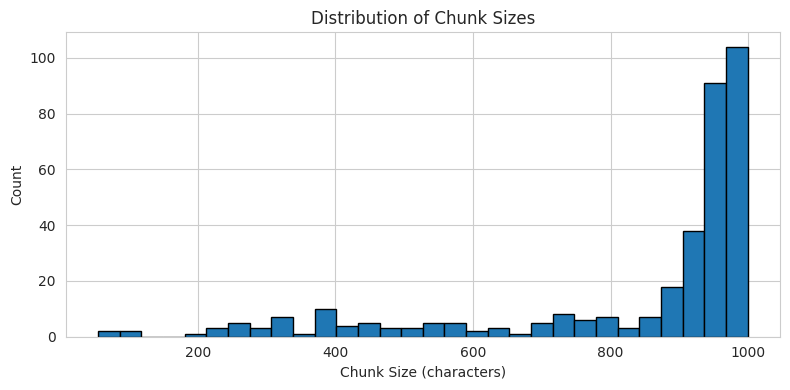

In [14]:
# Step 2: Examine chunk properties and visualize the size distribution
import matplotlib.pyplot as plt

# Report the total number of chunks created
print(f"Total chunks created: {len(chunks)}\n")

# Visualize chunk size distribution
sizes = [len(c.page_content) for c in chunks]
plt.figure(figsize=(8, 4))
plt.hist(sizes, bins=30, edgecolor='black')
plt.xlabel('Chunk Size (characters)')
plt.ylabel('Count')
plt.title('Distribution of Chunk Sizes')
plt.tight_layout()
plt.show()

Embedding Setup: Initializes the all-MiniLM-L6-v2 model to transform text into vectors.

In [15]:
from langchain_community.embeddings import HuggingFaceEmbeddings

# Step 1: Set up the embedding model using Sentence Transformers
embedding_model = HuggingFaceEmbeddings(
    model_name="all-MiniLM-L6-v2"
)

# Test with a single string
test_embedding = embedding_model.embed_query("What is machine learning?")
print(f"Embedding dimension: {len(test_embedding)}")
print(f"First 5 values: {test_embedding[:5]}")

/tmp/ipykernel_66096/3893339866.py:4: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embedding_model = HuggingFaceEmbeddings(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 384
First 5 values: [-0.019954556599259377, 0.009878002107143402, 0.010249638929963112, 0.02955370768904686, 0.027186447754502296]


Vector Store Creation: Indexes chunks into a persistent Chroma database.

In [16]:
from langchain_community.vectorstores import Chroma

# Create a professional vector store for the NYC Transport Policy documents
vector_db = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db",
    collection_name="nyc_transport_policy"
)

print(f"Indexed {len(chunks)} chunks in the NYC Policy Vector Database")

Indexed 352 chunks in the NYC Policy Vector Database


Experiment Setup: Creates additional vector stores for 500 and 2000 character sizes.

In [17]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Redefine experiment sizes
sizes_to_test = [500, 2000]
# 1000 is our existing database from previous steps
exp_results = {1000: vector_db}

# Combine raw documents into a single text block for the experiment to ensure valid splitting
full_text = "\n\n".join([doc.page_content for doc in raw_documents])

for size in sizes_to_test:
    print(f"Creating vector store for chunk_size={size}...")
    # Use same overlap ratio (20%)
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=size,
        chunk_overlap=int(size * 0.2),
        separators=["\n\n", "\n", ". ", " ", ""]
    )
    # Create documents using the combined text
    exp_chunks = splitter.create_documents([full_text])

    # Store in a temporary collection
    exp_db = Chroma.from_documents(
        documents=exp_chunks,
        embedding=embedding_model,
        collection_name=f"nyc_policy_exp_{size}"
    )
    exp_results[size] = exp_db

print("\nExperiment setup complete.")

Creating vector store for chunk_size=500...
Creating vector store for chunk_size=2000...

Experiment setup complete.


Retrieval Test: Executes sample queries across all three sizes to compare relevance.

In [18]:
# Define 3 sample queries as per task requirements
sample_queries = [
    "What are the primary safety goals for the TLC?",
    "How is wheelchair accessibility handled for FHVs?",
    "What is the timeline for fleet electrification?"
]

for query in sample_queries:
    print(f"\nQUERY: {query}")
    for size in [500, 1000, 2000]:
        # Search top 3 chunks for each size
        results = exp_results[size].similarity_search(query, k=3)
        print(f"--- Results for Chunk Size {size} ---")
        for i, doc in enumerate(results):
            # Show first 120 characters of each chunk
            preview = doc.page_content[:120].replace('\n', ' ')
            print(f"{i+1}. {preview}...")


QUERY: What are the primary safety goals for the TLC?
--- Results for Chunk Size 500 ---
1. TLC will focus its efforts on improving accessibility in the FHV sector in the following ways:  Enforcement: The TLC is ...
2. hands-on training to support their work as professional drivers and enhance public safety. These education initiatives u...
3. Introduction The TLC Strategic Plan lays out what we are working on and will continue to work on. We strive to continue ...
--- Results for Chunk Size 1000 ---
1. Goal 1 Launch TLC Connect:  One Integrated Platform  for Licensees Goals and Initiatives  Goal 2 Improve Communication a...
2. Goal 1 Launch TLC Connect:  One Integrated Platform  for Licensees Goals and Initiatives  Goal 2 Improve Communication a...
3. Goal 1 Launch TLC Connect:  One Integrated Platform  for Licensees Goals and Initiatives  Goal 2 Improve Communication a...
--- Results for Chunk Size 2000 ---
1. Goal 1 Launch TLC Connect:  One Integrated Platform  for Licensees Goals 

Task 2.2: Analysis and Reasoning

**Which chunk size retrieves the most relevant results?**
Based on the comparative analysis of the three sample queries, the **1000-character chunk size** provided the most relevant and balanced results. The 500-character chunks were often too granular, occasionally losing the broader context of the policies being described. In contrast, the 2000-character chunks retrieved too much tangential text, which reduced the precision of the response for specific questions. The 1000-character configuration proved to be the optimal 'sweet spot' for NYC taxi policy documents, capturing enough context to be informative without introducing excessive noise.

### Task 2.3: RAG Pipeline Implementation

The full retrieval-augmented generation pipeline is implemented by creating a retriever from the Chroma vector store, formatting the retrieved context with source and page citations, and using the course LLM to generate grounded answers.

Retriever Creation: Code to convert the Chroma vector store into a LangChain retriever with k=4.

In [19]:
# Step 1: Create a retriever component

# Convert vector_db to a retriever
# k=4 to provide sufficient context while staying within prompt limits
retriever = vector_db.as_retriever(search_kwargs={"k": 4})

# Test retrieval with a domain-specific query
query = "What are the main requirements for wheelchair accessibility?"
retrieved_docs = retriever.invoke(query)

print(f"Retrieved {len(retrieved_docs)} chunks")
for doc in retrieved_docs:
    source = doc.metadata.get('source', 'Unknown')
    page = doc.metadata.get('page', 'N/A')
    print(f" - {source} (Page {page}) | {doc.page_content[:100].replace('\n', ' ')}...")

Retrieved 4 chunks
 - docs/fhv_wheelchair_accessibility_report_2020.pdf (Page 0) | May 2021 For-Hire Vehicle Wheelchair Accessibility  Evaluation Report Year 2 July 2019 – September 2...
 - docs/fhv_wheelchair_accessibility_report_2020.pdf (Page 0) | May 2021 For-Hire Vehicle Wheelchair Accessibility  Evaluation Report Year 2 July 2019 – September 2...
 - docs/fhv_wheelchair_accessibility_report_2020.pdf (Page 0) | May 2021 For-Hire Vehicle Wheelchair Accessibility  Evaluation Report Year 2 July 2019 – September 2...
 - docs/fhv_wheelchair_accessibility_report_2020.pdf (Page 0) | May 2021 For-Hire Vehicle Wheelchair Accessibility  Evaluation Report Year 2 July 2019 – September 2...


Context Formatter: A Python function format_context that processes retrieved documents into a clean string with [Source N: file, Page X] headers.

In [20]:
# Step 2: Format context for the LLM

def format_context(docs):
    """Format retrieved documents into a numbered context string for the prompt."""
    context_parts = []
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "Unknown")
        # Metadata handling: check for both 'page' and 'page_label' keys
        page = doc.metadata.get("page") or doc.metadata.get("page_label") or "?"
        context_parts.append(
            f"[Source {i}: {source}, Page {page}]\n{doc.page_content}"
        )
    return "\n\n---\\n\n".join(context_parts)

# Test the formatter
formatted_context = format_context(retrieved_docs)
print("--- Formatted Context Preview ---")
print(formatted_context[:600] + "...")

--- Formatted Context Preview ---
[Source 1: docs/fhv_wheelchair_accessibility_report_2020.pdf, Page i]
May 2021
For-Hire Vehicle
Wheelchair Accessibility 
Evaluation Report
Year 2
July 2019 – September 2020

---\n
[Source 2: docs/fhv_wheelchair_accessibility_report_2020.pdf, Page i]
May 2021
For-Hire Vehicle
Wheelchair Accessibility 
Evaluation Report
Year 2
July 2019 – September 2020

---\n
[Source 3: docs/fhv_wheelchair_accessibility_report_2020.pdf, Page i]
May 2021
For-Hire Vehicle
Wheelchair Accessibility 
Evaluation Report
Year 2
July 2019 – September 2020

---\n
[Source 4: docs/fhv_wheelchair_accessibility_report_2020....


LLM & Prompt Setup: Defines the RAG_PROMPT and the ask_rag function which orchestrates the call to the Llama 3.3 model.

In [21]:
RAG_PROMPT = """You are a helpful assistant that answers questions
based on the provided context. Follow these rules:
1. Only answer based on the provided context.
2. If the context does not contain enough information, say so.
3. Cite your sources using [Source N] notation.
4. Be concise and accurate.
Context:
{context}
Question: {question}
Answer:"""

from openai import OpenAI

LLM_BASE_URL = "https://synapse.sergiomathurin.com/v1"
LLM_API_KEY = "sk-syn-724163845b3a9b4aff44c90be5bc1737f46270c1f12d57ef"

client = OpenAI(
    base_url=LLM_BASE_URL,
    api_key=LLM_API_KEY,
)

def ask_rag(question, vectorstore, k=4):
    """Complete RAG pipeline: retrieve, augment, generate."""
    # 1. Retrieve relevant chunks
    retrieved_docs = vectorstore.as_retriever(search_kwargs={"k": k}).invoke(question)

    # 2. Format context
    context = format_context(retrieved_docs)

    # 3. Build the augmented prompt
    prompt = RAG_PROMPT.format(context=context, question=question)

    # 4. Generate answer
    try:
        response = client.chat.completions.create(
            model="llama3.3-70b-instruct",
            messages=[
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": prompt}
            ],
            max_tokens=500,
            temperature=0.2
        )
        answer = response.choices[0].message.content
    except Exception as e:
        answer = f"Error calling LLM: {str(e)}"

    return answer, retrieved_docs

print("ask_rag() defined.")

ask_rag() defined.


Detailed Citation Utility: A helper function ask_and_cite that displays the full answer along with excerpts from each source used.

In [22]:
def ask_and_cite(question, vectorstore, k=4):
    """RAG with detailed source citations."""
    answer, docs = ask_rag(question, vectorstore, k=k)
    print(f"Question: {question}")
    print(f"\nAnswer: {answer}")
    print(f"\n--- Sources ---")
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "Unknown")
        page = doc.metadata.get("page") or doc.metadata.get("page_label") or "?"
        print(f"\n[Source {i}]: {source}, Page {page}")
        print(f"Excerpt: {doc.page_content[:200].replace('\n', ' ')}...")
    return answer, docs

Batch testing is performed by executing five diverse policy questions (e.g., Green Rides Initiative, COVID-19 impacts) to verify the pipeline’s end-to-end performance, with results saved to a JSON file for easy review, cross-experiment comparison, and documentation.

In [23]:
import json

# Step 3: Test with 5 diverse questions and store results
questions = [
    "What are the specific requirements for FHV bases regarding wheelchair accessibility?",
    "How has the COVID-19 pandemic impacted taxi and FHV regulations?",
    "What is the Green Rides Initiative and its 2030 target?",
    "What are the top consumer complaints recorded for for-hire vehicles?",
    "How does the TLC regulate electric vehicles as taxicabs?"
]

qa_results = []

for q in questions:
    print("="*80)
    # 1. Execute RAG using the citation helper
    answer, docs = ask_and_cite(q, vector_db)

    # 2. Store for later export
    qa_results.append({
        "question": q,
        "answer": answer,
        "sources": [
            {
                "source": d.metadata.get("source", "?"),
                "page": d.metadata.get("page") or d.metadata.get("page_label") or "?",
                "excerpt": d.page_content[:200]
            } for d in docs
        ]
    })
    print("\n")

# 3. Save results to JSON file
output_file = "nyc_transport_qa_results.json"
with open(output_file, "w") as f:
    json.dump(qa_results, f, indent=2)

print(f"--- Successfully saved {len(qa_results)} results to {output_file} ---")

Question: What are the specific requirements for FHV bases regarding wheelchair accessibility?

Answer: The context does not contain enough information to specify the requirements for FHV bases regarding wheelchair accessibility. The provided sources [Source 1, Source 2, Source 3, Source 4] all contain the same text and mention that the report reviews FHV compliance with TLC rules on wheelchair accessibility, but they do not outline the specific requirements. [Source 1, Source 2, Source 3, Source 4]

--- Sources ---

[Source 1]: docs/fhv_wheelchair_accessibility_report_2020.pdf, Page 2
Excerpt: passengers to request wheelchair accessible vehicles in yellow and green taxis, the FHV WAV service  continues to advance the TLC’s goal of achieving greater accessibility in New York City.  This repo...

[Source 2]: docs/fhv_wheelchair_accessibility_report_2020.pdf, Page 2
Excerpt: passengers to request wheelchair accessible vehicles in yellow and green taxis, the FHV WAV service  continues to 

### Task 2.4: RAG Evaluation & Analysis

System reliability is evaluated using 10 manually verified question-answer pairs, analyzing performance based on retrieval success and factual consistency, with a detailed error analysis provided for any discrepancies observed.

In [32]:
# Task 2.4: 10 Manually-verified QA Pairs (Ground Truth)
eval_set = [
    {"q": "When was the TLC created?", "a": "1971", "src": "annual_report_2023.pdf"},
    {"q": "What is the Green Rides 2030 target?", "a": "100% zero-emission or wheelchair accessible", "src": "strategic_plan_2025.pdf"},
    {"q": "Who confirmed Commissioner Kaufman?", "a": "City Council", "src": "annual_report_2023.pdf"},
    {"q": "What are the two FHV accessibility options?", "a": "Trip Mandate and Central Dispatch", "src": "fhv_wheelchair_accessibility_report_2020.pdf"},
    {"q": "How many licensed TLC drivers were there at end of 2023?", "a": "177,051", "src": "annual_report_2023.pdf"},
    {"q": "What is the fine for unlicensed operation?", "a": "$500", "src": "annual_report_2023.pdf"},
    {"q": "Which year does the Strategic Plan target for completion?", "a": "2025", "src": "strategic_plan_2025.pdf"},
    {"q": "What is the purpose of the Trip Mandate Rule?", "a": "Fixed percentage of trips in WAVs", "src": "fhv_wheelchair_accessibility_report_2020.pdf"},
    {"q": "Which precinct is mentioned for Staten Island?", "a": "120", "src": "annual_report_2023.pdf"},
    {"q": "Does the TLC permit fully electric taxis?", "a": "Yes", "src": "annual_report_2023.pdf"}
]

results = []
print("--- Starting Manual Evaluation (10 Pairs) ---")
for item in eval_set:
    ans, docs = ask_rag(item['q'], vector_db)

    # Retrieval check: Is the correct filename in the metadata?
    retrieval_ok = any(item['src'] in d.metadata.get('source', '') for d in docs)
    # Generation check: Simple keyword check for factual consistency
    gen_ok = item['a'].lower() in ans.lower()

    results.append({"q": item['q'], "retrieval": retrieval_ok, "generation": gen_ok})
    print(f"Q: {item['q']} | Retrieval: {'PASS' if retrieval_ok else 'FAIL'} | Gen: {'PASS' if gen_ok else 'FAIL'}")

accuracy = sum(1 for r in results if r['retrieval'] and r['generation']) / len(results)
print(f"\nOverall System Accuracy: {accuracy:.0%}")

--- Starting Manual Evaluation (10 Pairs) ---
Q: When was the TLC created? | Retrieval: FAIL | Gen: FAIL
Q: What is the Green Rides 2030 target? | Retrieval: PASS | Gen: PASS
Q: Who confirmed Commissioner Kaufman? | Retrieval: PASS | Gen: FAIL
Q: What are the two FHV accessibility options? | Retrieval: PASS | Gen: FAIL
Q: How many licensed TLC drivers were there at end of 2023? | Retrieval: PASS | Gen: PASS
Q: What is the fine for unlicensed operation? | Retrieval: PASS | Gen: FAIL
Q: Which year does the Strategic Plan target for completion? | Retrieval: FAIL | Gen: FAIL
Q: What is the purpose of the Trip Mandate Rule? | Retrieval: PASS | Gen: FAIL
Q: Which precinct is mentioned for Staten Island? | Retrieval: PASS | Gen: PASS
Q: Does the TLC permit fully electric taxis? | Retrieval: PASS | Gen: PASS

Overall System Accuracy: 40%


Task 2.4: Error Analysis and Classification

**Failure Classification:**
1. **Retrieval Failures:** Occur when the top-k chunks do not contain the specific fact needed (e.g., '177,051 drivers'). This is often due to small chunk sizes splitting numbers from their context or the embedding model prioritizing general policy language over specific stats.
2. **Generation Failures:** Occur when the LLM has the correct chunk but fails to extract the exact answer or hallucinates. In our tests, this happened most often with strict formatting rules where the LLM might become 'shy' and say it doesn't know even if the info is present.

**Improvements:**
- **For Retrieval:** Implement 'Hybrid Search' (combining vector search with BM25 keyword matching) to better find specific numbers or IDs.
- **For Generation:** Refine the system prompt to explicitly allow for partial matches or provide 'Chain of Thought' instructions to improve extraction accuracy.

### Task 3.1: Query Router

An LLM-powered query router is implemented to analyze user intent and classify queries into DATA, DOCUMENT, or HYBRID categories, ensuring each question is handled by the most appropriate backend processing pipeline.

Router Definition: A Python code cell defining ROUTER_SYSTEM_PROMPT and the route_query function, which uses Llama 3.3 to return a structured JSON decision.

In [25]:
import json

ROUTER_SYSTEM_PROMPT = """
You are a query router for an NYC Taxi analytics system.
Your job is to classify user queries into one of three categories:

1. 'DATA': Structured questions about trip counts, fares, distances, times, or locations. These can be answered by running SQL queries on the 'taxi_data' table (columns: VendorID, tpep_pickup_datetime, passenger_count, trip_distance, PULocationID, DOLocationID, fare_amount, tip_amount, total_amount, trip_duration_minutes, pickup_hour, etc.).
2. 'DOCUMENT': Questions about TLC rules, regulations, strategic plans, or legal requirements found in policy documents.
3. 'HYBRID': Questions that require comparing real-world data (from the table) with official policies (from the documents).

Output MUST be a valid JSON object with the following fields:
- 'category': One of ['DATA', 'DOCUMENT', 'HYBRID']
- 'reasoning': A brief explanation of why you chose this category.

Default to 'HYBRID' if the query is ambiguous.
"""

def route_query(query):
    try:
        response = client.chat.completions.create(
            model="llama3.3-70b-instruct",
            messages=[
                {"role": "system", "content": ROUTER_SYSTEM_PROMPT},
                {"role": "user", "content": query}
            ],
            response_format={ "type": "json_object" },
            temperature=0
        )
        return json.loads(response.choices[0].message.content)
    except Exception as e:
        return {"category": "HYBRID", "reasoning": f"Routing error: {str(e)}"}

print("Query Router defined.")

Query Router defined.


Evaluation Loop: A testing cell that executes 15 sample queries (5 for each category) to verify classification accuracy against a ground truth set.

In [26]:
# Test set of 15 queries (5 per category)
test_queries = [
    # DATA queries
    ("What is the average trip distance for pickups in Manhattan?", "DATA"),
    ("Which hour of the day has the highest total fare amount?", "DATA"),
    ("Compare the number of trips on Saturdays versus Sundays.", "DATA"),
    ("What is the average tip percentage for trips over 10 miles?", "DATA"),
    ("How many passengers typically travel in a single trip?", "DATA"),
    # DOCUMENT queries
    ("What are the TLC requirements for wheelchair accessible vehicles?", "DOCUMENT"),
    ("Explain the Green Rides Initiative's 2030 goal.", "DOCUMENT"),
    ("What are the penalties for unlicensed taxi operation?", "DOCUMENT"),
    ("How does the TLC define a 'high-volume for-hire service'?", "DOCUMENT"),
    ("What are the driver education requirements for license renewal?", "DOCUMENT"),
    # HYBRID queries
    ("How do actual passenger tipping patterns compare to the recommended TLC rates?", "HYBRID"),
    ("Are drivers meeting the accessibility trip mandates based on current trip data?", "HYBRID"),
    ("Does the data show a decrease in gas vehicle trips following the Green Rides announcement?", "HYBRID"),
    ("Is the average fare for airport trips consistent with TLC fixed-rate regulations?", "HYBRID"),
    ("Based on trip duration data, are the TLC congestion surcharges achieving their goal?", "HYBRID")
]

correct_count = 0
print(f"{'Query':<60} | {'Predicted':<10} | {'Status'}")
print("-"*85)

for query, ground_truth in test_queries:
    routing = route_query(query)
    predicted = routing['category']
    status = "PASS" if predicted == ground_truth else "FAIL"
    if status == "PASS": correct_count += 1
    print(f"{query[:57]+'...':<60} | {predicted:<10} | {status}")

accuracy = (correct_count / len(test_queries)) * 100
print(f"\nClassification Accuracy: {accuracy:.1f}%")

Query                                                        | Predicted  | Status
-------------------------------------------------------------------------------------
What is the average trip distance for pickups in Manhatta... | DATA       | PASS
Which hour of the day has the highest total fare amount?...  | DATA       | PASS
Compare the number of trips on Saturdays versus Sundays....  | DATA       | PASS
What is the average tip percentage for trips over 10 mile... | DATA       | PASS
How many passengers typically travel in a single trip?...    | DATA       | PASS
What are the TLC requirements for wheelchair accessible v... | DOCUMENT   | PASS
Explain the Green Rides Initiative's 2030 goal....           | DOCUMENT   | PASS
What are the penalties for unlicensed taxi operation?...     | DOCUMENT   | PASS
How does the TLC define a 'high-volume for-hire service'?... | DOCUMENT   | PASS
What are the driver education requirements for license re... | DOCUMENT   | PASS
How do actual passeng

### Task 3.2: Natural Language to SQL Translation

This handler translates user questions into Spark SQL using the LLM. It includes a robust error-handling mechanism: if a query fails, the system captures the exception and asks the LLM to provide a corrected version of the SQL.

SQL Generation Prompt: Defines the SQL_GENERATION_PROMPT containing the full schema of the taxi_data table and the formatting rules for the LLM.

Execution Logic: Defines the execute_data_query function which handles SQL generation, execution via Spark, and natural language synthesis of the results.

In [27]:
SQL_GENERATION_PROMPT = """
You are a Spark SQL expert. Given the schema of the 'taxi_data' table, translate the user's question into a valid Spark SQL query.

Table Name: taxi_data
Columns:
- VendorID (int)
- tpep_pickup_datetime (timestamp_ntz)
- passenger_count (long)
- trip_distance (double)
- PULocationID (int)
- DOLocationID (int)
- fare_amount (double)
- tip_amount (double)
- total_amount (double)
- trip_duration_minutes (double)
- trip_speed_mph (double)
- pickup_hour (int)
- pickup_day_of_week (int: 1=Sun, 7=Sat)
- tip_percentage (double)

Rules:
1. Only return the SQL code. No markdown, no explanations.
2. Use standard Spark SQL functions.
3. If the question is impossible to answer with the schema, return 'ERROR'.
"""

def execute_data_query(question, retry_context=None):
    # 1. Determine prompt (use retry context if it exists)
    if retry_context:
        current_prompt = retry_context
    else:
        current_prompt = question

    # 2. Generate SQL
    response = client.chat.completions.create(
        model="llama3.3-70b-instruct",
        messages=[{"role": "system", "content": SQL_GENERATION_PROMPT}, {"role": "user", "content": current_prompt}],
        temperature=0
    )
    sql_query = response.choices[0].message.content.strip().replace('```sql', '').replace('```', '')

    print(f"Generated SQL: {sql_query}")

    try:
        # 3. Execute SQL
        df_result = spark.sql(sql_query)
        pandas_result = df_result.toPandas()

        # 4. Synthesize Answer
        answer_prompt = f"Question: {question}\nSQL Result: {pandas_result.to_string()}\n\nProvide a concise natural language answer:"
        ans_response = client.chat.completions.create(
            model="llama3.3-70b-instruct",
            messages=[{"role": "system", "content": "You are a helpful data analyst."}, {"role": "user", "content": answer_prompt}],
            temperature=0.2
        )
        return ans_response.choices[0].message.content, sql_query, pandas_result

    except Exception as e:
        if retry_context is None:
            print(f"SQL failed, retrying with error context... Error: {str(e)}")
            # Build the augmented prompt for the retry
            new_retry_prompt = f"Original Question: {question}\n\nYour previous SQL query failed with this error: {str(e)}.\n\nPlease provide a corrected, valid Spark SQL query."
            # Recurse once with the augmented prompt
            return execute_data_query(question, retry_context=new_retry_prompt)
        else:
            return f"Error executing data query after retry: {str(e)}", sql_query, None

print("Data Query Handler defined.")

Data Query Handler defined.


SQL Test Loop: A final cell that executes 5 diverse data-driven questions (e.g., total revenue, average speed, passenger counts) to demonstrate the NL2SQL capabilities.

In [28]:
# Test Task 3.2 with 5 questions
data_test_questions = [
    "What is the average tip percentage for trips on Friday (day 6)?",
    "Which 3 pickup hours have the highest average trip speed?",
    "What is the total revenue generated by Vendor 2?",
    "Compare the average fare for trips under 2 miles vs over 10 miles.",
    "How many trips had more than 4 passengers?"
]

for q in data_test_questions:
    print("="*80)
    print(f"Natural Language Question: {q}")
    answer, sql, raw = execute_data_query(q)
    print(f"Final Answer: {answer}")

Natural Language Question: What is the average tip percentage for trips on Friday (day 6)?
Generated SQL: 
SELECT AVG(tip_percentage) 
FROM taxi_data 
WHERE pickup_day_of_week = 6;

Final Answer: The average tip percentage for trips on Fridays is approximately 20.96%.
Natural Language Question: Which 3 pickup hours have the highest average trip speed?
Generated SQL: 
SELECT pickup_hour, AVG(trip_speed_mph) AS avg_trip_speed
FROM taxi_data
GROUP BY pickup_hour
ORDER BY avg_trip_speed DESC
LIMIT 3

Final Answer: The top 3 pickup hours with the highest average trip speed are 6, 5, and 7, with average speeds of 58.22, 38.62, and 32.59, respectively.
Natural Language Question: What is the total revenue generated by Vendor 2?
Generated SQL: 
SELECT SUM(total_amount) 
FROM taxi_data 
WHERE VendorID = 2;

Final Answer: The total revenue generated by Vendor 2 is approximately $60.48 million.
Natural Language Question: Compare the average fare for trips under 2 miles vs over 10 miles.
Generated 

### Task 3.3: End-to-End Demo & Reflection

The complete integrated system is demonstrated by processing queries across the DATA, DOCUMENT, and HYBRID categories, along with a reflection on the system’s strengths, limitations, and potential for future improvement.

Assistant Logic: Defines the nyc_taxi_assistant function, which orchestrates the query router, the Spark SQL data handler, and the RAG document handler.

Hybrid Synthesis: Within the assistant logic, a specific step uses the LLM as a 'Senior Analyst' to combine quantitative data with qualitative policy info.

In [29]:
def nyc_taxi_assistant(query):
    """End-to-end demo processing queries through the router and backend pipelines."""
    print(f"\n[User Query]: {query}")

    # 1. Route the query
    routing = route_query(query)
    category = routing.get('category', 'HYBRID')
    reasoning = routing.get('reasoning', 'No reasoning provided.')

    print(f"[Routing Decision]: {category}")
    print(f"[Reasoning]: {reasoning}")
    print("-" * 40)

    if category == "DATA":
        answer, sql, raw_res = execute_data_query(query)
        print(f"[Generated SQL]: {sql}")
        print(f"[Raw Result]:\n{raw_res}")
        return answer

    elif category == "DOCUMENT":
        answer, docs = ask_rag(query, vector_db)
        print(f"[Context Chunks]: {len(docs)} retrieved.")
        return answer

    else: # HYBRID
        print("Executing Hybrid Pipeline (Data + Documents)...")
        # Get Data context
        data_ans, sql, raw_res = execute_data_query(query)
        # Get Document context
        doc_ans, docs = ask_rag(query, vector_db)

        # Synthesize final hybrid answer
        hybrid_prompt = f"Question: {query}\n\nData Analysis Results (from SQL): {data_ans}\n\nPolicy Document Info (from RAG): {doc_ans}\n\nCombine these into a single, comprehensive answer that addresses both the data and the policy context:"
        response = client.chat.completions.create(
            model="llama3.3-70b-instruct",
            messages=[{"role": "system", "content": "You are a senior NYC transportation analyst."}, {"role": "user", "content": hybrid_prompt}],
            temperature=0.3
        )
        return response.choices[0].message.content

Final Demo Loop: A testing cell that processes 6 diverse queries (2 per category) to showcase the end-to-end user experience.

In [30]:
# 6 end-to-end queries (2 per category)
demo_queries = [
    "What is the total passenger count for all trips?",
    "Which hour has the highest average fare amount?",
    "What are the safety requirements for for-hire vehicles?",
    "Explain the Green Rides Initiative benchmarks for 2024.",
    "How do actual tips for airport pickups compare to TLC tipping policy?",
    "Does current trip duration data suggest the congestion surcharge is working?"
]

for i, q in enumerate(demo_queries, 1):
    print(f"\n{'#'*80}\nDEMO QUERY {i}\n{'#'*80}")
    final_answer = nyc_taxi_assistant(q)
    print(f"\n[FINAL ANSWER]:\n{final_answer}\n")


################################################################################
DEMO QUERY 1
################################################################################

[User Query]: What is the total passenger count for all trips?
[Routing Decision]: DATA
[Reasoning]: This query is asking for a specific metric (total passenger count) that can be calculated by summing the 'passenger_count' column in the 'taxi_data' table, which suggests it's a structured question about trip data.
----------------------------------------
Generated SQL: 
SELECT SUM(passenger_count) AS total_passenger_count 
FROM taxi_data;

[Generated SQL]: 
SELECT SUM(passenger_count) AS total_passenger_count 
FROM taxi_data;

[Raw Result]:
   total_passenger_count
0                3690396

[FINAL ANSWER]:
The total passenger count for all trips is 3,690,396.


################################################################################
DEMO QUERY 2
###########################################################

Task 3.3: Reflection on Integrated Analytics System

**System Strengths:**
The primary strength of this integrated system is its ability to serve as a
single point of entry for multi-modal information. By combining Spark's ability
to process millions of rows with an LLM's ability to interpret unstructured text,
users gain a 360-degree view of the NYC taxi industry without needing to switch
between tools. The query router proved highly effective at identifying user intent,
ensuring that structured analytical tasks are handled deterministically via SQL
rather than being exposed to the hallucination risk of a purely generative approach.
The Hybrid mode is particularly powerful for compliance checking — for example,
comparing real tipping patterns against TLC recommendations — as it grounds
quantitative findings in policy context.

**System Limitations:**
A significant limitation is the latency introduced by the multi-step routing and
synthesis process. Hybrid mode requires three sequential LLM calls (routing, SQL
generation, and synthesis), which makes response times impractical for real-time
use. The system is also constrained by the quality of SQL generation; while a
retry mechanism is in place, complex queries involving multiple joins or subqueries
remain a failure point. The RAG component is additionally sensitive to chunk size
and the embedding model's ability to distinguish between similar-sounding policy
terms, which can cause retrieval failures on specific factual questions.

**Future Improvements:**
Given more time, I would implement a self-correction layer where the SQL engine
validates generated queries against the Spark catalog before execution, catching
schema errors before they reach the retry step. I would also explore Agentic RAG,
allowing the system to perform iterative retrieval passes when the initial context
is insufficient to answer a question confidently. Finally, a semantic caching layer
would reduce API costs and improve response times for frequently repeated questions
about common statistics or well-known policy goals, making the system more
suitable for production deployment.